# Object Detection:

Face Detection using Cascade Classifier using OpenCV 

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt



In [4]:
face_cascade = cv2.CascadeClassifier("/content/haarcascade_frontalface_default.xml")
eye_cascade = cv2.CascadeClassifier('/content/haarcascade_eye.xml')

In [5]:
def adjusted_detect_face(img):
    face_img = img.copy()
    face_rect = face_cascade.detectMultiScale(face_img, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in face_rect:
        cv2.rectangle(face_img, (x, y), (x + w, y + h), (255, 255, 255), 10)

    return face_img

In [6]:
def detect_eyes(img):
    eye_img = img.copy()
    eye_rect = eye_cascade.detectMultiScale(eye_img, scaleFactor=1.2, minNeighbors=5)

    for (x, y, w, h) in eye_rect:
        cv2.rectangle(eye_img, (x, y), (x + w, y + h), (255, 255, 255), 10)
        
    return eye_img

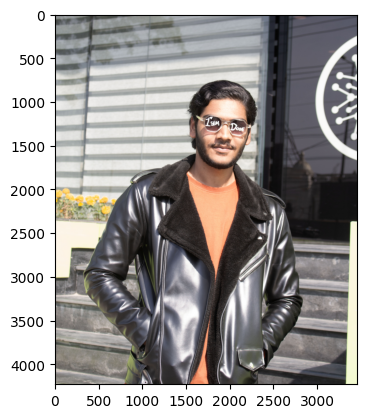

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("C:/Users/User/Desktop/open cv/IMG_1188 copy.jpg")

img_copy1 = img.copy()
img_copy2 = img.copy()
img_copy3 = img.copy()

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

### Face Detection

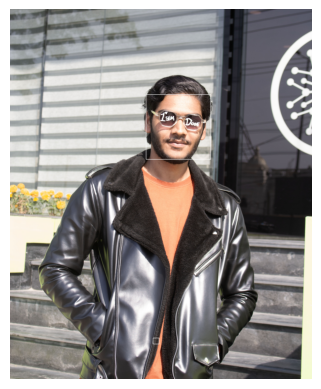

In [13]:
import cv2
import matplotlib.pyplot as plt

# Load face cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 
                                     'haarcascade_frontalface_default.xml')

# Read image
img = cv2.imread("C:/Users/User/Desktop/open cv/IMG_1188 copy.jpg")

# Convert to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# Draw rectangle
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x,y), (x+w,y+h), (255,255,255), 4)

# Show image
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

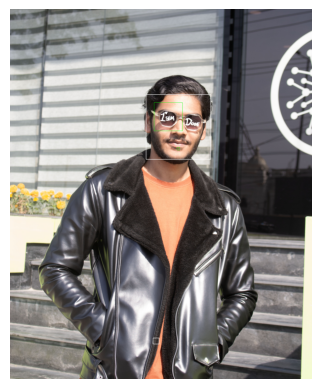

In [15]:
# Load eye cascade
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Convert image to gray
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces first
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

# For each face, detect eyes
for (x, y, w, h) in faces:
    roi_gray = gray[y:y+h, x:x+w]      # Face region gray
    roi_color = img[y:y+h, x:x+w]      # Face region color

    eyes = eye_cascade.detectMultiScale(roi_gray)

    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)

# Show the result
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

### Find and Draw Contours using OpenCV - Python

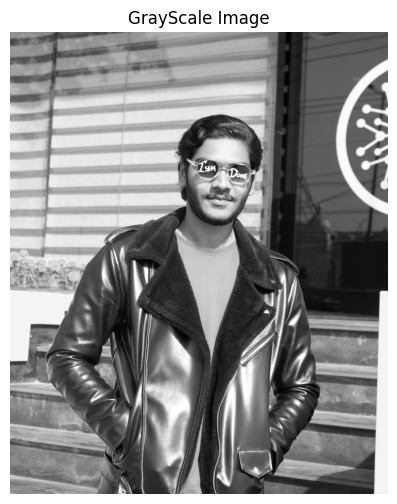

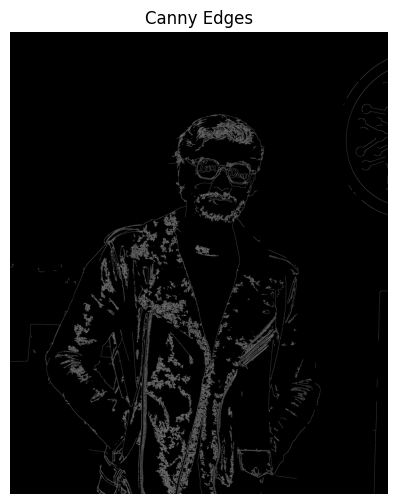

Number of Contours Found = 2488


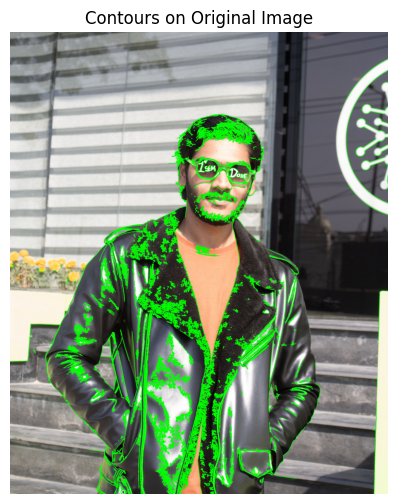

In [22]:
import cv2
import matplotlib.pyplot as plt

# Step 1: Load image
image = cv2.imread("C:\\Users\\User\\Desktop\\open cv\\IMG_1188 copy.jpg")

if image is None:
    print("Image path incorrect!")
else:
    # Step 2: Convert to GrayScale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    plt.figure(figsize=(8,6))
    plt.imshow(gray, cmap='gray')
    plt.title("GrayScale Image")
    plt.axis("off")
    plt.show()

    # Step 3: Edge Detection using Canny
    edged = cv2.Canny(gray, 30, 200)
    plt.figure(figsize=(8,6))
    plt.imshow(edged, cmap='gray')
    plt.title("Canny Edges")
    plt.axis("off")
    plt.show()

    # Step 4: Finding Contours (external only)
    contours, hierarchy = cv2.findContours(edged, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)

    # Step 5: Print number of contours found
    print("Number of Contours Found = " + str(len(contours)))

    # Step 6: Draw contours on the original image
    image_with_contours = image.copy()
    cv2.drawContours(image_with_contours, contours, -1, (0, 255, 0), 3)

    # Step 7: Display the image with contours
    image_rgb = cv2.cvtColor(image_with_contours, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8,6))
    plt.imshow(image_rgb)
    plt.title("Contours on Original Image")
    plt.axis("off")
    plt.show()

### Measure Size of an Object Using Python OpenCV

### Detect Polygons in an Image using OpenCV

In [1]:
import cv2

# Step 1: Load the image
img = cv2.imread("C:\\Users\\User\\Desktop\\open cv\\IMG_1188 copy.jpg")

if img is None:
    print("Image path incorrect!")
    exit()

# Step 2: Resize image for faster processing (50% size)
img = cv2.resize(img, (0, 0), fx=0.5, fy=0.5)
img_display = img.copy()

# Step 3: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Threshold to separate object from background
ret, thresh = cv2.threshold(gray, 127, 255, 0)

# Step 5: Find contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Step 6: Draw contours on the resized image
cv2.drawContours(img_display, contours, -1, (0, 255, 0), 3)

# Step 7: Calculate area of the first contour (pixels -> real units)
if len(contours) > 0:
    area = cv2.contourArea(contours[0])
    scale_factor = 0.1  # Example: 1 pixel = 0.1 cm
    size = area * scale_factor ** 2
    print('Size of the first object:', size)
else:
    print("No contours found!")

# Step 8: Save and display the image
output_path = "C:\\Users\\User\\Desktop\\open cv\\object_with_contours_fast.jpg"
cv2.imwrite(output_path, img_display)

cv2.imshow('Object with Contours', img_display)
cv2.waitKey(0)
cv2.destroyAllWindows()

Size of the first object: 0.0


### Arrow / Polygon Detection

In [1]:
import cv2
import numpy as np

# Step 1: Load the image
img_color = cv2.imread("C:\\Users\\User\\Desktop\\open cv\\IMG_1188 copy.jpg", cv2.IMREAD_COLOR)
img_gray = cv2.imread("C:\\Users\\User\\Desktop\\open cv\\IMG_1188 copy.jpg", cv2.IMREAD_GRAYSCALE)

if img_color is None or img_gray is None:
    print("Image path incorrect!")
    exit()

# Step 2: Resize for faster processing (50% size)
img_color = cv2.resize(img_color, (0, 0), fx=0.5, fy=0.5)
img_gray = cv2.resize(img_gray, (0, 0), fx=0.5, fy=0.5)

# Step 3: Convert to binary (black & white)
_, threshold = cv2.threshold(img_gray, 110, 255, cv2.THRESH_BINARY)

# Step 4: Find contours
contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Step 5: Detect 7-sided polygons (arrow)
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 400:  # Filter small regions
        approx = cv2.approxPolyDP(cnt, 0.009 * cv2.arcLength(cnt, True), True)
        if len(approx) == 7:
            cv2.drawContours(img_color, [approx], 0, (0, 0, 255), 5)

# Step 6: Display the image
cv2.imshow('Arrow Detection (Fast)', img_color)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Step 7: Save output image
cv2.imwrite("C:\\Users\\User\\Desktop\\open cv\\IMG_1188_arrow_detected_fast.jpg", img_color)

True

# Feature Detection:

### SIFT Interest Point Detector

In [ ]:
import cv2

# Step 1: Load image
image_path = "C:\\Users\\User\\Desktop\\open cv\\IMG_1188 copy.jpg"
img = cv2.imread(image_path)

if img is None:
    print("Image path incorrect!")
    exit()

# Step 2: Resize image to 25% for ultra-fast processing
scale_percent = 25  # 25% of original size
width = int(img.shape[1] * scale_percent / 100)
height = int(img.shape[0] * scale_percent / 100)
dim = (width, height)
img = cv2.resize(img, dim)

# Step 3: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 4: Create SIFT detector
sift = cv2.SIFT_create()

# Step 5: Detect keypoints
kp = sift.detect(gray, None)

# Step 6: Draw keypoints on the image
img_with_kp = cv2.drawKeypoints(
    gray, 
    kp, 
    img, 
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Step 7: Save and display
output_path = "C:\\Users\\User\\Desktop\\open cv\\IMG_1188_SIFT_keypoints_ultrafast.jpg"
cv2.imwrite(output_path, img_with_kp)

cv2.imshow("SIFT Keypoints ", img_with_kp)
cv2.waitKey(0)
cv2.destroyAllWindows()

print("SIFT keypoints detection completed. Output saved at:", output_path)

### Feature matching using ORB algorithm

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

query_img_path = "C:\\Users\\User\\Desktop\\open cv\\IMG_1188 copy.jpg"       # Query image
train_img_path = "C:\\Users\\User\\Desktop\\open cv\\IMG_1188_train.jpg"    # Train image

query_img = cv2.imread(query_img_path)
train_img = cv2.imread(train_img_path)

if query_img is None or train_img is None:
    print("One or both image paths are incorrect!")
    exit()
scale_percent = 25  # 25% size
def resize_img(img, scale_percent):
    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)
    return cv2.resize(img, (width, height))

query_img = resize_img(query_img, scale_percent)
train_img = resize_img(train_img, scale_percent)

query_img_bw = cv2.cvtColor(query_img, cv2.COLOR_BGR2GRAY)
train_img_bw = cv2.cvtColor(train_img, cv2.COLOR_BGR2GRAY)

orb = cv2.ORB_create()
queryKeypoints, queryDescriptors = orb.detectAndCompute(query_img_bw, None)
trainKeypoints, trainDescriptors = orb.detectAndCompute(train_img_bw, None)

matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
matches = matcher.match(queryDescriptors, trainDescriptors)
matches = sorted(matches, key=lambda x: x.distance)  # Best matches first

final_img = cv2.drawMatches(query_img, queryKeypoints, 
                            train_img, trainKeypoints, matches[:20], None, flags=2)

# Resize for display
final_img = cv2.resize(final_img, (1000, 650))

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(final_img, cv2.COLOR_BGR2RGB))
plt.title("ORB Feature Matches")
plt.axis('off')
plt.show()
output_path = "C:\\Users\\User\\Desktop\\open cv\\ORB_feature_matches_ultrafast.jpg"
cv2.imwrite(output_path, final_img)
print("ORB feature matching completed. Output saved at:", output_path)

One or both image paths are incorrect!


AttributeError: 'NoneType' object has no attribute 'shape'

: 

### BFMatcher Feature Matching Code

In [ ]:
import cv2
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load your images
# -----------------------------
img1 = cv2.imread("C:\\Users\\User\\Desktop\\open cv\\IMG_1188 copy.jpg")
img2 = cv2.imread("C:\\Users\\User\\Desktop\\open cv\\IMG_1188_train.jpg")  # second image

if img1 is None or img2 is None:
    print("Image path incorrect!")
    exit()

# -----------------------------
# Step 2: Resize images to 25% (for faster processing)
# -----------------------------
scale = 25

def resize_image(img, scale):
    width = int(img.shape[1] * scale / 100)
    height = int(img.shape[0] * scale / 100)
    return cv2.resize(img, (width, height))

img1 = resize_image(img1, scale)
img2 = resize_image(img2, scale)

# -----------------------------
# Step 3: Feature Matching Function
# -----------------------------
def BFMatching(img1, img2):

    # ORB detector (faster than SIFT)
    feat = cv2.ORB_create(500)

    # Detect keypoints and descriptors
    kpnt1, des1 = feat.detectAndCompute(img1, None)
    kpnt2, des2 = feat.detectAndCompute(img2, None)

    # BFMatcher
    bf = cv2.BFMatcher(cv2.NORM_HAMMING)

    # KNN matching
    matches = bf.knnMatch(des1, des2, k=2)

    good = []

    # Ratio test
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good.append([m])

    # Draw matches
    matched_image = cv2.drawMatchesKnn(
        img1, kpnt1,
        img2, kpnt2,
        good[:20], None,
        matchColor=(0,255,0),
        singlePointColor=(255,0,0),
        flags=0
    )

    # Show result
    cv2.imshow("Feature Matches", matched_image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # Save output
    cv2.imwrite("C:\\Users\\User\\Desktop\\open cv\\BFMatcher_result.jpg", matched_image)

    print("Keypoints in first image:", len(kpnt1))
    print("Keypoints in second image:", len(kpnt2))
    print("Good matches found:", len(good))

    return good


# Run the function
BFMatching(img1, img2)